<a href="https://colab.research.google.com/github/Lamiya-56/internship-data-analytics/blob/main/Sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/sales_data_sample.csv', encoding='latin-1')
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [3]:
df.shape

(2823, 25)

In [4]:
df.dtypes

,0
ORDERNUMBER,int64
QUANTITYORDERED,int64
PRICEEACH,float64
ORDERLINENUMBER,int64
SALES,float64
ORDERDATE,object
STATUS,object
QTR_ID,int64
MONTH_ID,int64
YEAR_ID,int64


In [5]:
df.isnull().sum()

,0
ORDERNUMBER,0
QUANTITYORDERED,0
PRICEEACH,0
ORDERLINENUMBER,0
SALES,0
ORDERDATE,0
STATUS,0
QTR_ID,0
MONTH_ID,0
YEAR_ID,0


In [6]:
(df.isnull().sum() / len(df)) * 100

,0
ORDERNUMBER,0.000000
QUANTITYORDERED,0.000000
PRICEEACH,0.000000
ORDERLINENUMBER,0.000000
SALES,0.000000
ORDERDATE,0.000000
STATUS,0.000000
QTR_ID,0.000000
MONTH_ID,0.000000
YEAR_ID,0.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [9]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [10]:
df['ORDERDATE']

,ORDERDATE
0,2/24/2003 0:00
1,5/7/2003 0:00
2,7/1/2003 0:00
3,8/25/2003 0:00
4,10/10/2003 0:00
...,...
2818,12/2/2004 0:00
2819,1/31/2005 0:00
2820,3/1/2005 0:00
2821,3/28/2005 0:00


In [11]:
# Convert ORDERDATE to datetime format
df['ORDERDATE']=pd.to_datetime(df['ORDERDATE'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDERNUMBER       2823 non-null   int64         
 1   QUANTITYORDERED   2823 non-null   int64         
 2   PRICEEACH         2823 non-null   float64       
 3   ORDERLINENUMBER   2823 non-null   int64         
 4   SALES             2823 non-null   float64       
 5   ORDERDATE         2823 non-null   datetime64[ns]
 6   STATUS            2823 non-null   object        
 7   QTR_ID            2823 non-null   int64         
 8   MONTH_ID          2823 non-null   int64         
 9   YEAR_ID           2823 non-null   int64         
 10  PRODUCTLINE       2823 non-null   object        
 11  MSRP              2823 non-null   int64         
 12  PRODUCTCODE       2823 non-null   object        
 13  CUSTOMERNAME      2823 non-null   object        
 14  PHONE             2823 n

In [13]:
# Handle missing values
# Fill specific columns with "Unknown"
cols_to_fill=["ADDRESSLINE2", "STATE", "POSTALCODE", "TERRITORY"]
for col in cols_to_fill:
  df[col]=df[col].fillna('Unknown')

df.isnull().sum()

,0
ORDERNUMBER,0
QUANTITYORDERED,0
PRICEEACH,0
ORDERLINENUMBER,0
SALES,0
ORDERDATE,0
STATUS,0
QTR_ID,0
MONTH_ID,0
YEAR_ID,0


In [14]:
# Export the cleaned dataset
df.to_csv('cleaned_sales_data.csv', index=False)

In [15]:
df['STATUS'].value_counts(normalize=True)

,proportion
STATUS,
Shipped,0.927028
Cancelled,0.021254
Resolved,0.016649
On Hold,0.015586
In Process,0.014524
Disputed,0.004959


In [16]:
status_percentages = df['STATUS'].value_counts(normalize=True)*100
status_percentages

,proportion
STATUS,
Shipped,92.702798
Cancelled,2.125399
Resolved,1.664896
On Hold,1.558626
In Process,1.452356
Disputed,0.495926


In [17]:
df['YEAR_ID'].value_counts().sort_values(ascending=False).head(1)

,count
YEAR_ID,
2004,1345


In [18]:
df['PRODUCTLINE'].value_counts()

,count
PRODUCTLINE,
Classic Cars,967
Vintage Cars,607
Motorcycles,331
Planes,306
Trucks and Buses,301
Ships,234
Trains,77


#**Visualizations**

##Histogram of SALES column

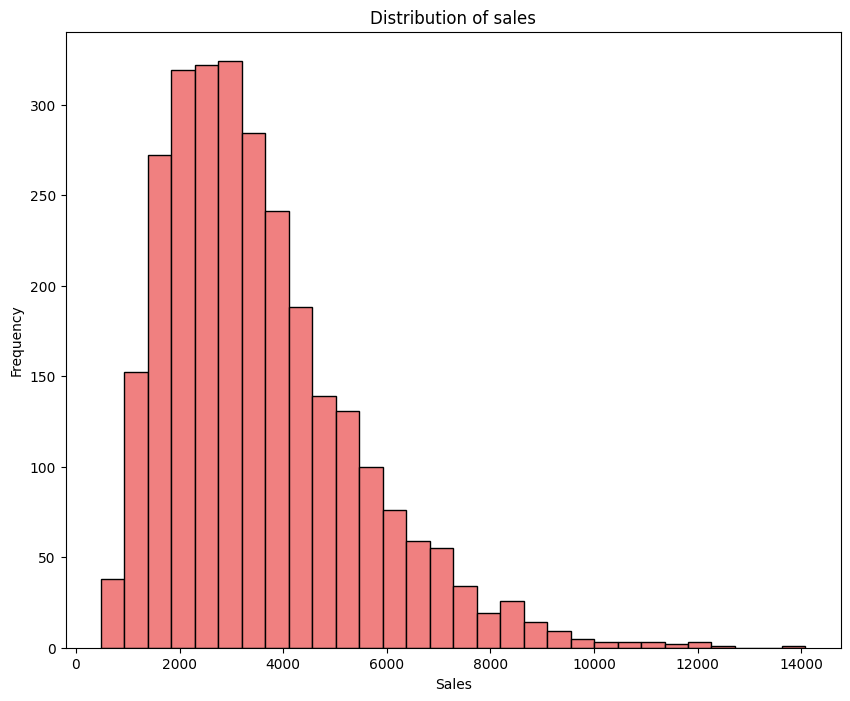

In [19]:
plt.figure(figsize=(10, 8))
plt.hist(df['SALES'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution of sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.savefig('sales_histogram.png')
plt.show()

In [74]:
df['SALES'].describe()

,SALES
count,2823.000000
mean,3553.889072
std,1841.865106
min,482.130000
25%,2203.430000
50%,3184.800000
75%,4508.000000
max,14082.800000


Orta satışla maksimum satış arasındakı fərq təxminən 4 qatdır. Bu, biznesin "kütləvi" satışlarla (2k-4k) ayaqda qaldığını, lakin 14k-lıq böyük sifarişlərin gəlirliliyi kəskin artırdığını göstərir. Əsas gəlir mənbəyi 2,000-4,000 aralığındadır; 10,000-dən yuxarı satışlar isə nadir, lakin kritikdir, çünki o aralıqdakı həmin o bir neçə sifarişin gətirdiyi pul, yüzlərlə kiçik sifarişin gətirdiyi pula bərabərdir. Onlar biznesin mənfəəti əhəmiyyətli dərəcədə artırır.

##Bar chart of order count by YEAR_ID

In [20]:
year_counts = df['YEAR_ID'].value_counts().sort_index()
year_counts

,count
YEAR_ID,
2003,1000
2004,1345
2005,478


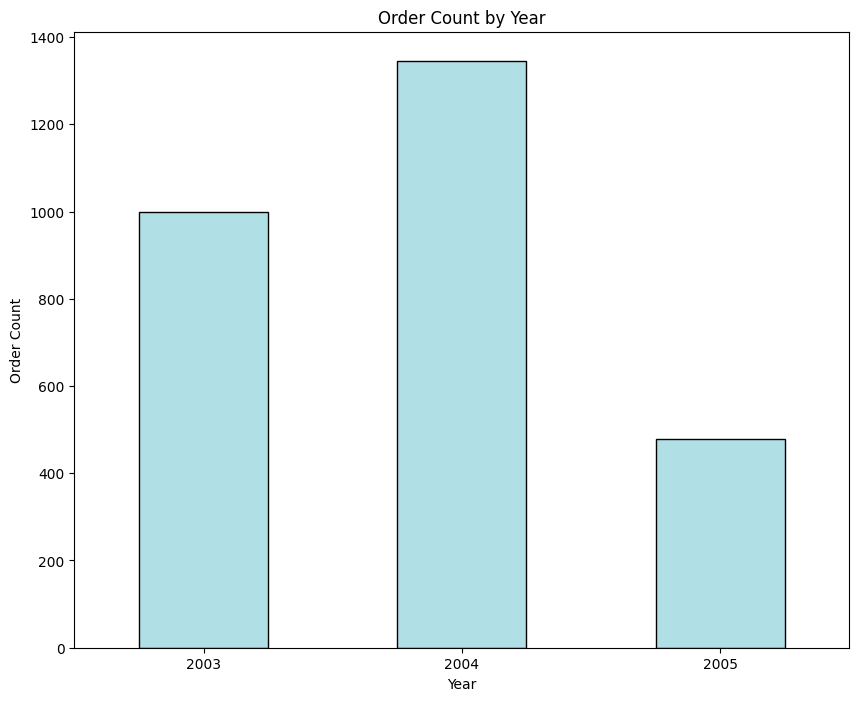

In [21]:
plt.figure(figsize=(10, 8))
year_counts.plot(kind='bar',color='powderblue',edgecolor='black')
plt.title('Order Count by Year')
plt.xlabel('Year')
plt.ylabel('Order Count')
plt.xticks(rotation=0)
plt.savefig('order_by_year.png')
plt.show()

Sifarişlərin 47.6%-i (1345/2823) 2004-cü ildə baş verib. Bu, şirkətin tarixində ən yüksək aktivlik dövrüdür. 2005-ci ildə sifariş sayı 2004-ə nisbətən demək olar ki, yarıya enib. Bu, şirkətin 2005-ci ildə ciddi bazar itkisi yaşadığını göstərir.

##Bar chart of top 5 countries by order count

In [22]:
country_counts=df['COUNTRY'].value_counts().sort_values(ascending=False).head(5)
country_counts

,count
COUNTRY,
USA,1004
Spain,342
France,314
Australia,185
UK,144


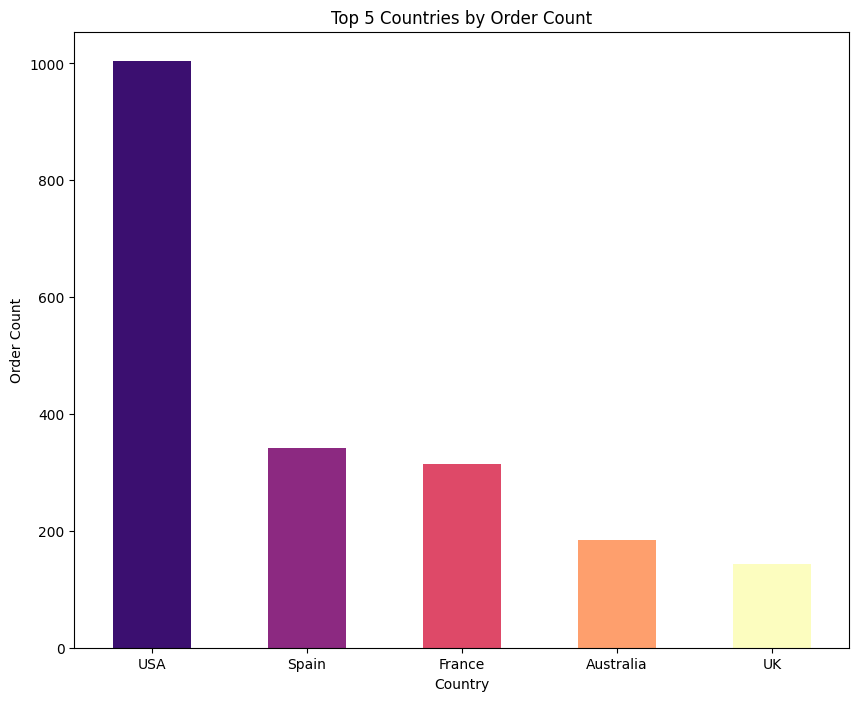

In [73]:
import numpy as np
# Generate colors from magma colormap for each country
# Start from 0.2 to avoid very dark colors
colors = plt.cm.magma(np.linspace(0.2, 1, len(country_counts)))

plt.figure(figsize=(10, 8))
country_counts.plot(kind='bar', color=colors)
plt.title('Top 5 Countries by Order Count')
plt.xlabel('Country')
plt.ylabel('Order Count')
plt.xticks(rotation=0)
plt.savefig('top_5_countries.png')
plt.show()

ABŞ təkbaşına ümumi sifarişlərin 35.6%-ni (1004/2823) təşkil edir. İkinci və üçüncü yerdə olan İspaniya və Fransanın cəmi (656 sifariş) belə ABŞ-ın göstəricisindən 35% aşağıdır. Biznes ABŞ bazarından həddindən artıq asılıdır. Həmin bazarda baş verəcək hər hansı problem gəlirlərin 1/3 hissəsinin birbaşa risk altına düşməsi deməkdir.